# Data Case 2 – NYC Marathon
**Data Science 2025-2026 | Pandas - Matplotlib**

---

In deze opdracht werk je met de **winnaarslijst van de New York City Marathon** van 1970 tot 2020.  
De dataset bevat voor elk jaar de winnaar bij de mannen én de vrouwen, hun land, eindtijd en eventuele records.

Je leert:
- Een **CSV-bestand** inlezen, verkennen en opkuisen met **pandas**
- **Beschrijvende statistieken** berekenen: gemiddelde, mediaan, percentielen, IQR
- Trends en vergelijkingen **visualiseren** met **matplotlib**
- Grafieken correct opmaken met titels, aslabels, legenda en annotaties
- queries over je data te beantwoorden

Zorg dat `marathon.csv` in dezelfde map staat als deze notebook.

## Stap 0 – Bibliotheken importeren

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

print("Alle bibliotheken geladen ✓")

Alle bibliotheken geladen ✓


---
## Deel 1 – CSV inlezen en opkuisen

### 1.1 – Bestand inlezen

Lees `marathon.csv` in met `pd.read_csv()` en sla op als `df`. Bekijk de eerste 8 rijen.

In [5]:
df = pd.read_csv("../data/marathon.csv")
print(df.head(8))

   year            name        country      time  time_hrs division  \
0  1970    Gary Muhrcke  United States  02:31:38  2.527222      Men   
1  1970             NaN            NaN       NaN       NaN    Women   
2  1971  Norman Higgins  United States  02:22:54  2.381667      Men   
3  1971     Beth Bonner  United States  02:55:22  2.922778    Women   
4  1972  Sheldon Karlin  United States  02:27:52  2.464444      Men   
5  1972    Nina Kuscsik  United States  03:08:41  3.144722    Women   
6  1973     Tom Fleming  United States  02:21:54  2.365000      Men   
7  1973    Nina Kuscsik  United States  02:57:07  2.951944    Women   

                 note  
0       Course record  
1  No woman finishers  
2       Course record  
3        World record  
4                 NaN  
5                 NaN  
6       Course record  
7      Second victory  


### 1.2 – Eerste verkenning

Beantwoord de vragen hieronder met de juiste pandas-methodes.

- Hoeveel rijen en kolommen zijn er? 
- Wat zijn de kolomnamen en hun bijbehorende datatypes? 
- zijn er ontbrekende waarden?
- Geef een beknopte statistiek van de verschillende features/kolommen

In [3]:
print(f"Er zijn {df.shape[0]} rijen en {df.shape[1]} kolommen.")
print(df.dtypes)
print(f"Zijn er ontbrekende waarden? {df.isna().any().any()}")
df.describe()

Er zijn 102 rijen en 7 kolommen.
year          int64
name            str
country         str
time            str
time_hrs    float64
division        str
note            str
dtype: object
Zijn er ontbrekende waarden? True


,year,time_hrs
count,102.000000,99.000000
mean,1995.000000,2.350295
std,14.792291,0.211797
min,1970.000000,2.085000
25%,1982.250000,2.165556
50%,1995.000000,2.385833
75%,2007.750000,2.456389
max,2020.000000,3.144722


### 1.3 – Data opkuisen

Je merkt dat sommige rijen `NA` bevatten als tekst (bv. de geannuleerde editie 2012 door Hurricane Sandy, of 1970 bij de vrouwen).  
Pandas heeft die **niet** automatisch herkend als ontbrekende waarden.

Lees de CSV opnieuw in met de parameter `na_values=["NA"]` zodat die cellen wél als `NaN` worden ingelezen.  
Verwijder daarna alle rijen waarbij `time_hrs` ontbreekt.
Hoeveel rijen blijven er nu nog over?

In [6]:
df = pd.read_csv("../data/marathon.csv", na_values=["NA"])
df.dropna(subset=["time_hrs"], inplace=True)
print(f"Er zijn nog {df.shape[0]} rijen")

Er zijn nog 99 rijen


### 1.4 – Filteren en selecteren

**1.4a:** Maak twee aparte DataFrames: `df_m` (mannen) en `df_v` (vrouwen).  
**1.4b:** Welke atleet won ooit het snelst? Geef naam, jaar en tijd.  
**1.4c:** Hoeveel verschillende landen leverden ooit een winnaar?

In [8]:
# 1.4a
df_m = df[df["division"] == "Men"]
df_v = df[df["division"] == "Women"]

# 1.4b
kortst = min(df["time"])
snelste = df[df["time"] == kortst]
print(f"{snelste["name"].iloc[0]} won het snelste in {snelste["year"].iloc[0].astype(int)} met een tijd van: {snelste["time"].iloc[0]}")

# 1.4c
print(f"Er zijn {len(pd.unique(df["country"]))} verschillende landen die een winnaar leverden.")
print(df["country"].nunique())

Geoffrey Mutai won het snelste in 2011 met een tijd van: 02:05:06
Er zijn 20 verschillende landen die een winnaar leverden.
20


---
## Deel 2 – Beschrijvende statistieken

### 2.1 – Basismaten per divisie

Bereken voor **mannen** én **vrouwen** afzonderlijk:  
gemiddelde, mediaan, standaardafwijking, minimum en maximum van `time_hrs`.

> 💡 Gebruik `np.mean()`, `np.median()`, `np.std()`, `np.min()`, `np.max()`

In [9]:
print("Vrouwen:")
print(np.mean(df_v["time_hrs"]), np.median(df_v["time_hrs"]), np.std(df_v["time_hrs"]), np.min(df_v["time_hrs"]), np.max(df_v["time_hrs"]))

print("\nMannen:")
print(np.mean(df_m["time_hrs"]), np.median(df_m["time_hrs"]), np.std(df_m["time_hrs"]), np.min(df_m["time_hrs"]), np.max(df_m["time_hrs"]))

Vrouwen:
2.50718253968254 2.45 0.17831080628553064 2.375277777777778 3.144722222222222

Mannen:
2.196544444444444 2.1655555555555557 0.0948812474154462 2.085 2.527222222222222


### 2.2 – Percentielen en IQR

Bereken voor mannen én vrouwen het 25ste percentiel (Q1), het 75ste percentiel (Q3) en de IQR.  

Bij welke divisie is de spreiding groter? Wat kan dat verklaren?

In [10]:
print("Vrouwen:")
Q1_v = df_v["time_hrs"].quantile(0.25)
Q3_v = df_v["time_hrs"].quantile(0.75)
IQR_v = Q3_v - Q1_v
print(Q1_v, Q3_v, IQR_v)

print("\nMannen:")
Q1_m = df_m["time_hrs"].quantile(0.25)
Q3_m = df_m["time_hrs"].quantile(0.75)
IQR_m = Q3_m - Q1_m
print(Q1_m, Q3_m, IQR_m)

# De spreiding is groter bij de vrouwen. Er is meer verschil tussen de tijden bij de vrouwen dan bij de mannen.

Vrouwen:
2.418055555555556 2.4811111111111117 0.06305555555555564

Mannen:
2.1454166666666667 2.190625 0.04520833333333307


### 2.3 – Decenniumanalyse

Voeg een kolom `decennium` toe aan `df` (bv. 1970, 1980, 1990 ...).  
Bereken daarna per decennium het **gemiddelde** van `time_hrs`, opgesplitst voor mannen en vrouwen.
**Tip:**  maak gebruik van `groupby` 

In [11]:
df["decennium"] = (np.floor(df["year"] / 10) * 10).astype(int)
gem_per_dec_per_geslacht = df.groupby(["decennium", "division"])["time_hrs"].mean()
gem_per_dec_per_geslacht

decennium  division
1970       Men         2.326306
           Women       2.809784
1980       Men         2.168806
           Women       2.459139
1990       Men         2.166833
           Women       2.454111
2000       Men         2.154083
           Women       2.412389
2010       Men         2.141142
           Women       2.412932
2020       Men         2.396667
           Women       2.591111
Name: time_hrs, dtype: float64

---
## Deel 3 – Visualisaties met matplotlib

### 3.1 – Lijnplot: tijdstrend mannen én vrouwen

Maak een lijnplot met het jaar op de x-as en `time_hrs` op de y-as.  
Plot mannen en vrouwen als **twee afzonderlijke lijnen** in dezelfde grafiek.

Voeg toe:
- Titel, x-label, y-label
- Legenda
- Een horizontale stippellijn op het **gemiddelde van de mannen** en één op het **gemiddelde van de vrouwen**

> De y-as toont uren. Gebruik `ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f u'))` voor leesbare labels.

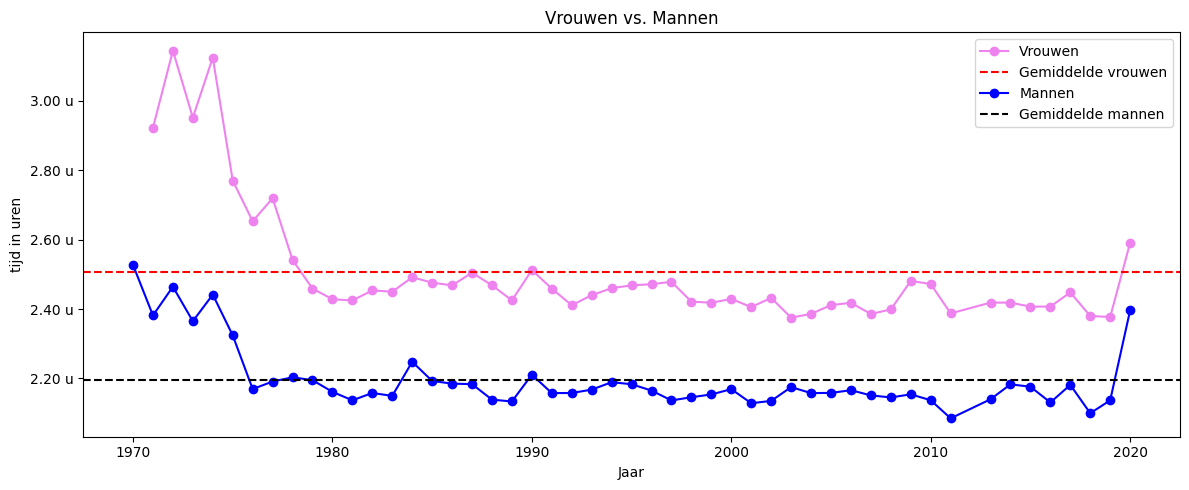

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

plt.title("Vrouwen vs. Mannen")
plt.xlabel("Jaar")
plt.ylabel("tijd in uren")
plt.plot(df_v["year"], df_v["time_hrs"], color="violet", label="Vrouwen", marker="o")
plt.axhline(np.mean(df_v["time_hrs"]), color="red", linestyle="--", label="Gemiddelde vrouwen")
plt.plot(df_m["year"], df_m["time_hrs"], color="blue", label="Mannen", marker="o")
plt.axhline(np.mean(df_m["time_hrs"]), color="black", linestyle="--", label="Gemiddelde mannen")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f u'))
plt.legend()

plt.tight_layout()
plt.show()

### 3.2 – Histogram: verdeling winningstijden

Maak **twee histogrammen naast elkaar** (`plt.subplots(1, 2)`): één voor mannen, één voor vrouwen.  
Gebruik 8 bins. Duid in elk histogram het gemiddelde én de mediaan aan met verticale lijnen.

Zijn de verdelingen symmetrisch of scheef? Wat zie je aan het verschil tussen gemiddelde en mediaan?

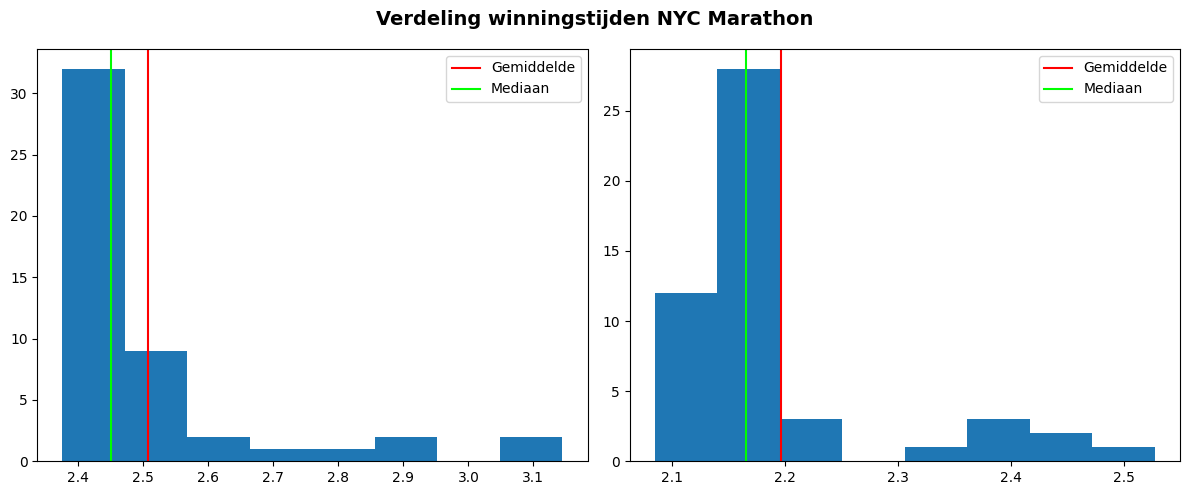

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(df_v["time_hrs"], bins=8)
ax1.axvline(np.mean(df_v["time_hrs"]), color="red", label="Gemiddelde")
ax1.axvline(np.median(df_v["time_hrs"]), color="lime", label="Mediaan")
ax1.legend()

ax2.hist(df_m["time_hrs"], bins=8)
ax2.axvline(np.mean(df_m["time_hrs"]), color="red", label="Gemiddelde")
ax2.axvline(np.median(df_m["time_hrs"]), color="lime", label="Mediaan")
ax2.legend()

fig.suptitle("Verdeling winningstijden NYC Marathon", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Beide verdelingen zijn scheef. Het verschil tussen gemiddelde en mediaan ziet er hetzelfde uit voor mannen en vrouwen.
# De mediaan is telkens kleiner/lager dan het gemiddelde.


### 3.3 – Boxplot: mannen vs. vrouwen + percentielbanden

Maak een boxplot met mannen en vrouwen naast elkaar in **één subplot**.  
Voeg via `ax.axhspan()` een **transparante band** toe die het Q1–Q3-gebied van de mannen markeert.

**Tip:** `ax.boxplot([data1, data2], labels=["Mannen", "Vrouwen"], patch_artist=True)` plaatst beide naast elkaar.

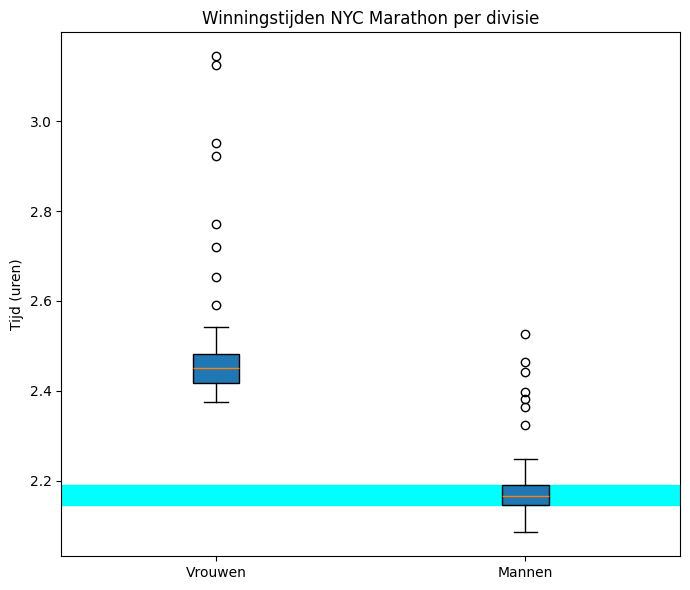

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.boxplot([df_v["time_hrs"], df_m["time_hrs"]], tick_labels=["Vrouwen", "Mannen"], patch_artist=True)
ax.axhspan(Q1_m, Q3_m, color="cyan")

ax.set_title("Winningstijden NYC Marathon per divisie")
ax.set_ylabel("Tijd (uren)")
plt.tight_layout()
plt.show()

### 3.4 – Staafdiagram: gemiddelde per decennium

Maak een **gegroepeerd staafdiagram** dat per decennium de gemiddelde winningstijd toont voor mannen én vrouwen naast elkaar.  
Voeg foutbalken toe op basis van de standaardafwijking per groep.

> Gebruik `np.arange()` voor de x-posities en verschuif de staven met een kleine offset:  
> `ax.bar(x - 0.2, waarden_m, width=0.4, ...)` en `ax.bar(x + 0.2, waarden_v, width=0.4, ...)`

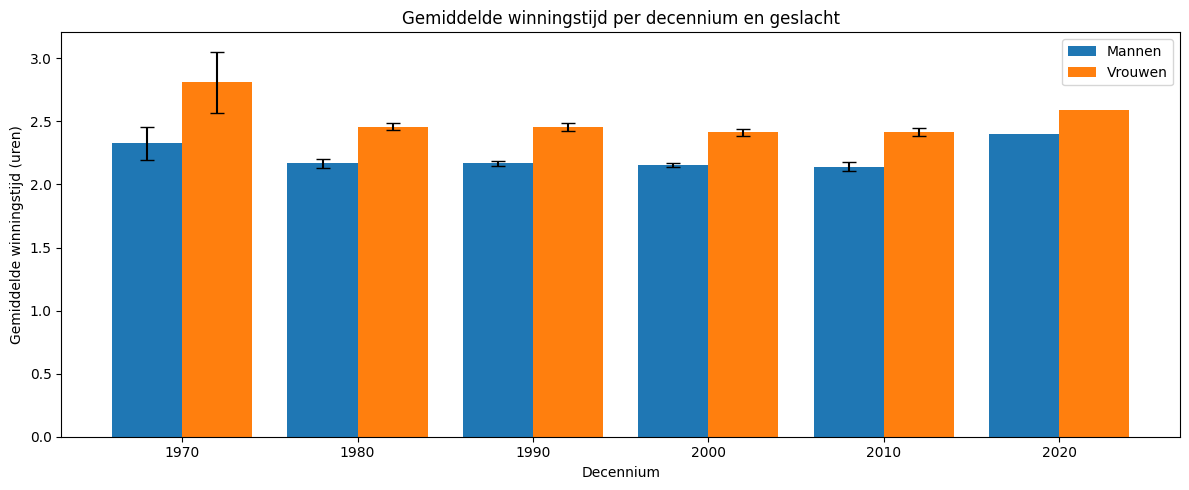

In [19]:
mean_plot = gem_per_dec_per_geslacht.unstack()
std_plot = df.groupby(["decennium", "division"])["time_hrs"].std().unstack()

x = np.arange(len(mean_plot))
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - 0.2, mean_plot["Men"], width=0.4, yerr=std_plot["Men"], capsize=5, label="Mannen")
ax.bar(x + 0.2, mean_plot["Women"], width=0.4, yerr=std_plot["Women"], capsize=5, label="Vrouwen")

ax.set_xticks(x)
ax.set_xticklabels(mean_plot.index)
ax.set_xlabel("Decennium")
ax.set_ylabel("Gemiddelde winningstijd (uren)")
ax.set_title("Gemiddelde winningstijd per decennium en geslacht")
ax.legend()

plt.tight_layout()
plt.show()

### 3.5 – Scatterplot: jaar vs. tijd met landkleur

Maak een scatterplot voor de **mannen** met het jaar op de x-as en `time_hrs` op de y-as.  
Kleur de punten op basis van het land van herkomst van de winnaar (beperk je tot de top-4 landen, de rest krijgt de kleur `"gray"`).

**Tip:** bepaal via `value_counts` eerst de top-4 landen. Plot dan elk land (de top 4 + overige) apart met `ax.scatter(...)` zodat de legende automatisch werkt.

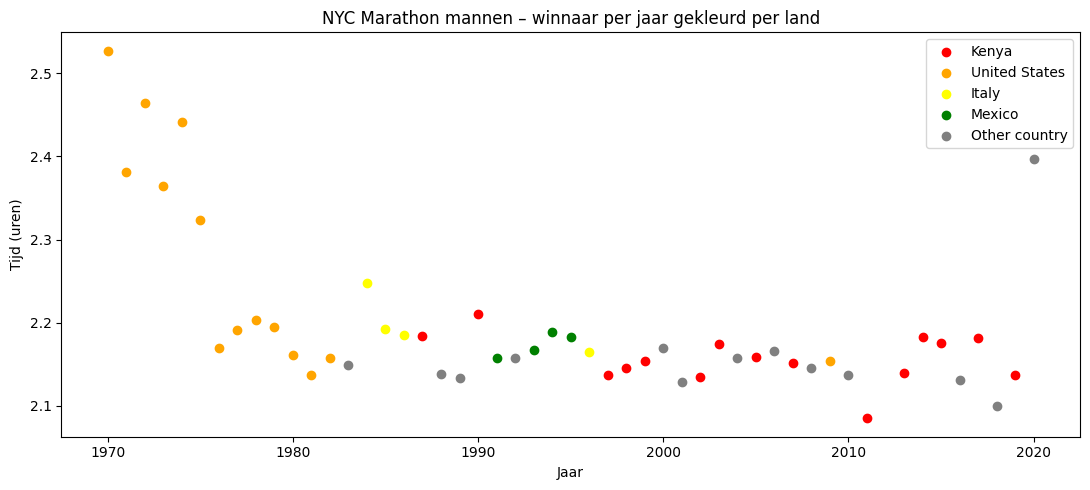

In [20]:
top4_landen = df_m["country"].value_counts().head(4).index

first = df_m.where(df_m["country"] == top4_landen[0])
second = df_m.where(df_m["country"] == top4_landen[1])
third = df_m.where(df_m["country"] == top4_landen[2])
fourth = df_m.where(df_m["country"] == top4_landen[3])
other = df_m.where(~df_m["country"].isin(top4_landen))

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(first["year"], first["time_hrs"], color="red", label=top4_landen[0])
ax.scatter(second["year"], second["time_hrs"], color="orange", label=top4_landen[1])
ax.scatter(third["year"], third["time_hrs"], color="yellow", label=top4_landen[2])
ax.scatter(fourth["year"], fourth["time_hrs"], color="green", label=top4_landen[3])
ax.scatter(other["year"], other["time_hrs"], color="gray", label="Other country")

ax.set_title("NYC Marathon mannen – winnaar per jaar gekleurd per land")
ax.set_xlabel("Jaar")
ax.set_ylabel("Tijd (uren)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Deel 4 – Dashboard

Maak één dashboard met een **2×2 raster** van subplots (`plt.subplots(2, 2)`) dat de vier vorige grafieken combineert:

| Positie | Grafiek |
|---|---|
| Linksboven | Lijnplot tijdstrend M + V |
| Rechtsboven | Histogrammen M + V (gebruik `plt.subplots(2, 2)` of twin axes) |
| Linksonder | Gegroepeerd staafdiagram per decennium |
| Rechtsonder | Scatterplot jaar vs. tijd met landkleur |

Sla de figuur op als `marathon_dashboard.png`.

**Tip:** maak elke grafiek eerst als losse functie, dan is het eenvoudig ze te combineren.

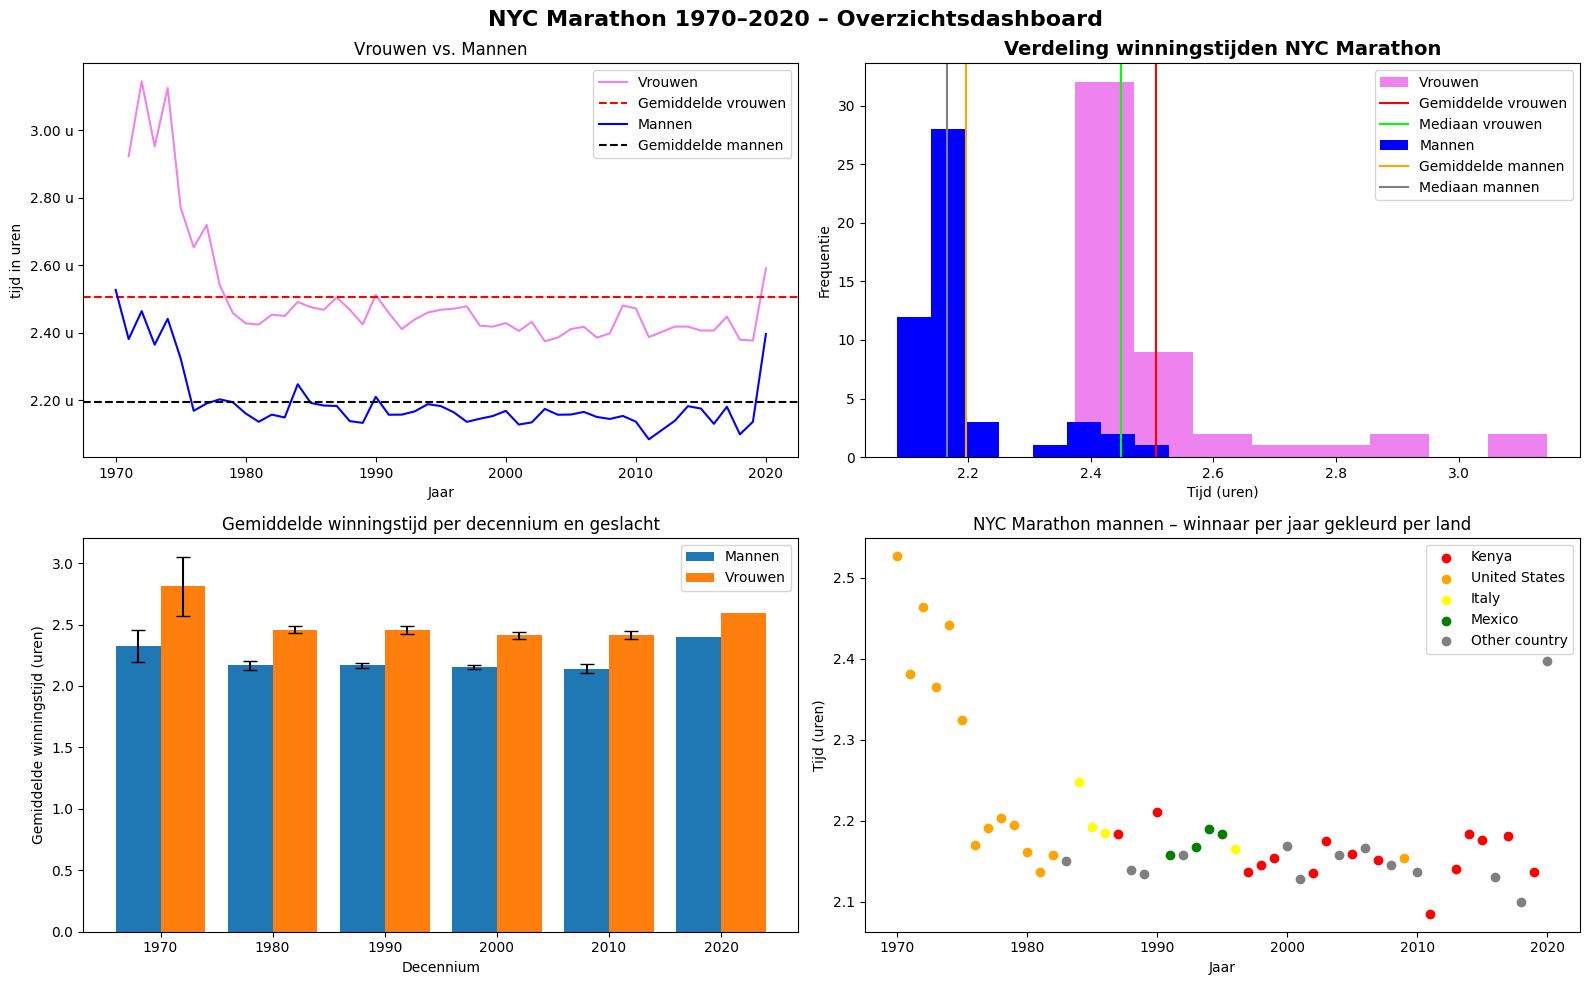

Dashboard opgeslagen als marathon_dashboard.png ✓


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("NYC Marathon 1970–2020 – Overzichtsdashboard", fontsize=16, fontweight="bold")

ax1, ax2, ax3, ax4 = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

# --- Linksboven: lijnplot trend ---
ax1.set_title("Vrouwen vs. Mannen")
ax1.set_xlabel("Jaar")
ax1.set_ylabel("tijd in uren")
ax1.plot(df_v["year"], df_v["time_hrs"], color="violet", label="Vrouwen")
ax1.axhline(np.mean(df_v["time_hrs"]), color="red", linestyle="--", label="Gemiddelde vrouwen")
ax1.plot(df_m["year"], df_m["time_hrs"], color="blue", label="Mannen")
ax1.axhline(np.mean(df_m["time_hrs"]), color="black", linestyle="--", label="Gemiddelde mannen")
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f u'))
ax1.legend()

# --- Rechtsboven: histogram M + V ---
ax2.hist(df_v["time_hrs"], bins=8, color="violet", label="Vrouwen")
ax2.axvline(np.mean(df_v["time_hrs"]), color="red", label="Gemiddelde vrouwen")
ax2.axvline(np.median(df_v["time_hrs"]), color="lime", label="Mediaan vrouwen")
ax2.legend()

ax2.hist(df_m["time_hrs"], bins=8, color="blue", label="Mannen")
ax2.axvline(np.mean(df_m["time_hrs"]), color="orange", label="Gemiddelde mannen")
ax2.axvline(np.median(df_m["time_hrs"]), color="gray", label="Mediaan mannen")
ax2.legend()

ax2.set_title("Verdeling winningstijden NYC Marathon", fontsize=14, fontweight="bold")
ax2.set_xlabel("Tijd (uren)")
ax2.set_ylabel("Frequentie")
plt.tight_layout()

# --- Linksonder: staafdiagram decennia ---
ax3.bar(x - 0.2, mean_plot["Men"], width=0.4, yerr=std_plot["Men"], capsize=5, label="Mannen")
ax3.bar(x + 0.2, mean_plot["Women"], width=0.4, yerr=std_plot["Women"], capsize=5, label="Vrouwen")

ax3.set_xticks(x)
ax3.set_xticklabels(mean_plot.index)
ax3.set_xlabel("Decennium")
ax3.set_ylabel("Gemiddelde winningstijd (uren)")
ax3.set_title("Gemiddelde winningstijd per decennium en geslacht")
ax3.legend()

# --- Rechtsonder: scatterplot landen ---
ax4.scatter(first["year"], first["time_hrs"], color="red", label=top4_landen[0])
ax4.scatter(second["year"], second["time_hrs"], color="orange", label=top4_landen[1])
ax4.scatter(third["year"], third["time_hrs"], color="yellow", label=top4_landen[2])
ax4.scatter(fourth["year"], fourth["time_hrs"], color="green", label=top4_landen[3])
ax4.scatter(other["year"], other["time_hrs"], color="gray", label="Other country")

ax4.set_title("NYC Marathon mannen – winnaar per jaar gekleurd per land")
ax4.set_xlabel("Jaar")
ax4.set_ylabel("Tijd (uren)")
ax4.legend()

plt.tight_layout()
plt.savefig("marathon_dashboard.png", dpi=150)
plt.show()
print("Dashboard opgeslagen als marathon_dashboard.png ✓")

---
## Deel 5 – Queries

### 5.1 – Wereldrecords

Geef alle edities waarbij een **wereldrecord** werd gevestigd.  
Toon enkel de kolommen `year`, `name`, `division`, `time` en `note`.

> Gebruik `.str.contains("zoekterm", na=False)` op de kolom `note`.  
> De parameter `na=False` zorgt dat `NaN`-waarden niet als fout worden behandeld.

In [22]:
world_records = df["note"].str.contains("World record", na=False)
df[world_records][["year", "name", "division", "time", "note"]]

,year,name,division,time,note
3,1971,Beth Bonner,Women,02:55:22,World record
17,1978,Grete Waitz,Women,02:32:30,World record
19,1979,Grete Waitz,Women,02:27:33,"World record second victory"""""""
21,1980,Grete Waitz,Women,02:25:42,"World record third victory"""""""


### 5.2 – Meervoudige winnaars

Welke atleten wonnen **meer dan één keer**? Hoeveel overwinningen had elk van hen?  
Sorteer van meest naar minst overwinningen.


In [23]:
multiple_winners = df["name"].value_counts()
mask = multiple_winners > 1
multiple_winners[mask]

name
Grete Waitz                 9
Bill Rodgers                4
Mary Keitany                4
Alberto Salazar             3
Paula Radcliffe             3
Nina Kuscsik                2
Tom Fleming                 2
Miki Gorman                 2
Orlando Pizzolato           2
Germn Silva                 2
Tegla Loroupe               2
John Kagwe                  2
Margaret Okayo              2
Martin Lel                  2
Jeena Prokopuka             2
Marlson Gomes dos Santos    2
Geoffrey Mutai              2
Geoffrey Kamworor           2
Name: count, dtype: int64

### 5.3 – Top 10 snelste edities

Geef de **10 snelste edities** ooit (los van divisie), gesorteerd van snel naar traag.  
Toon `year`, `name`, `division`, `time` en `time_hrs`.

> Tip: `.nsmallest`

In [25]:
snelste10 = df.nsmallest(10, "time_hrs")[["year", "name", "division", "time", "time_hrs"]]
snelste10

,year,name,division,time,time_hrs
82,2011,Geoffrey Mutai,Men,02:05:06,2.085000
96,2018,Lelisa Desisa,Men,02:05:59,2.099722
62,2001,Tesfaye Jifar,Men,02:07:43,2.128611
92,2016,Ghirmay Ghebreslassie,Men,02:07:51,2.130833
38,1989,Juma Ikangaa,Men,02:08:01,2.133611
64,2002,Rodgers Rop,Men,02:08:07,2.135278
54,1997,John Kagwe,Men,02:08:12,2.136667
22,1981,Alberto Salazar,Men,02:08:13,2.136944
98,2019,Geoffrey Kamworor,Men,02:08:13,2.136944
80,2010,Gebregziabher Gebremariam,Men,02:08:14,2.137222


### 5.4 – Grootste tijdskloof M vs. V per jaar

In welk jaar was de **tijdskloof** tussen de mannelijke en vrouwelijke winnaar het grootst?  
In welk jaar was die kloof het **kleinst**?

> Maak eerst `een pivot tabel`. Een pivot tabel is een manier om gegevens samen te vatten vanuit een grote tabel. Maak hier een tabel met als rijen de jaartallen, als kolommen voorzie je de 2 divisions en als value de 'time_hrs'. Doe dit met `df.pivot`.  
> Voeg dan een kolom `kloof` toe als het absolute verschil tussen beide tijden.

In [26]:
pivot = df.pivot(columns="division", index="year", values="time_hrs").dropna()
pivot["kloof"] = np.abs(pivot["Men"] - pivot["Women"])
sorted_pivot = pivot.sort_values("kloof")

print(f"De tijdskloof was het grootst in {sorted_pivot.index[-1]}.")
print(f"De tijdskloof was het kleinst in {sorted_pivot.index[0]}.")
pivot.head()

De tijdskloof was het grootst in 1974.
De tijdskloof was het kleinst in 2020.


division,Men,Women,kloof
year,,,
1971,2.381667,2.922778,0.541111
1972,2.464444,3.144722,0.680278
1973,2.365000,2.951944,0.586944
1974,2.441667,3.124722,0.683056
1975,2.324167,2.770556,0.446389


### 5.5 – Landen-rangschikking

Maak een overzichtstabel met per **land**:
- het aantal overwinningen
- de gemiddelde winningstijd
- de beste (= snelste) tijd ooit

Sorteer op aantal overwinningen (meest naar minst).

In [27]:
landen = (
    df.groupby("country")["time_hrs"]
    .agg(["count", "mean", "min"])
    .rename(columns={"count": "overwinningen", "mean": "gem_tijd", "min": "min_tijd"})
    .sort_values("overwinningen", ascending=False)
)
landen

,overwinningen,gem_tijd,min_tijd
country,,,
Kenya,27,2.273179,2.085000
United States,23,2.486957,2.136944
Norway,10,2.466278,2.425000
United Kingdom,7,2.381429,2.138889
Mexico,5,2.223278,2.157778
Italy,5,2.242444,2.165000
Ethiopia,5,2.246833,2.099722
Brazil,2,2.155694,2.145278
South Africa,2,2.157917,2.157778


### 5.6 – Nationaliteitsdiversiteit per decennium

Hoeveel **verschillende nationaliteiten** leverden per decennium een winnaar?  
Was de marathon in de beginjaren gedomineerd door één land?

> Tip: Tel geen dubbels!

In [28]:
diversiteit = df.groupby("decennium")["country"].nunique()
diversiteit

decennium
1970     2
1980     7
1990    10
2000     9
2010     4
2020     2
Name: country, dtype: int64

### 5.7 – Sneller dan het gemiddelde?

Voeg een kolom `boven_gemiddelde` toe: `True` als de winnaar **sneller** liep dan het gemiddelde van zijn/haar divisie.  
Hoeveel edities per divisie hadden een winningstijd onder het gemiddelde?

> Tip: Gebruik `.transform("mean")` ipv `.agg(mean` als je de groepsberekening naast je originele data wil zetten. 

In [29]:
gem_per_divisie = df.groupby("division")["time_hrs"].transform("mean")
print(gem_per_divisie)

df["boven_gemiddelde"] = df["time_hrs"] < gem_per_divisie
df

0      2.196544
2      2.196544
3      2.507183
4      2.196544
5      2.507183
         ...   
97     2.507183
98     2.196544
99     2.507183
100    2.196544
101    2.507183
Name: time_hrs, Length: 99, dtype: float64


,year,name,country,time,time_hrs,division,note,decennium,boven_gemiddelde
0,1970,Gary Muhrcke,United States,02:31:38,2.527222,Men,Course record,1970,False
2,1971,Norman Higgins,United States,02:22:54,2.381667,Men,Course record,1970,False
3,1971,Beth Bonner,United States,02:55:22,2.922778,Women,World record,1970,False
4,1972,Sheldon Karlin,United States,02:27:52,2.464444,Men,NaN,1970,False
5,1972,Nina Kuscsik,United States,03:08:41,3.144722,Women,NaN,1970,False
...,...,...,...,...,...,...,...,...,...
97,2018,Mary Keitany,Kenya,02:22:48,2.380000,Women,Fourth victory,2010,True
98,2019,Geoffrey Kamworor,Kenya,02:08:13,2.136944,Men,Second victory,2010,True
99,2019,Joyciline Jepkosgei,Kenya,02:22:38,2.377222,Women,NaN,2010,True
100,2020,Kevin Quinn,United Kingdom,02:23:48,2.396667,Men,Virtual event held due to the COVID-19,2020,False


### 5.8 – Rang per divisie

Voeg een kolom `rang` toe die elke winnaar **rangschikt** binnen zijn/haar divisie op basis van `time_hrs` (rang 1 = snelste ooit).

Wie staat op **rang 1** bij de mannen en bij de vrouwen?

> Gebruik de `.rank` methode om per divisie elke winnaar een rang toe te kennen.

In [30]:

df["rank"] = df.groupby("division")["time_hrs"].rank(method="min", ascending=True).astype(int)
df.sort_values(["rank"])


,year,name,country,time,time_hrs,division,note,decennium,boven_gemiddelde,rank
82,2011,Geoffrey Mutai,Kenya,02:05:06,2.085000,Men,Current course record,2010,True,1
67,2003,Margaret Okayo,Kenya,02:22:31,2.375278,Women,"Current course record, second victory",2000,True,1
99,2019,Joyciline Jepkosgei,Kenya,02:22:38,2.377222,Women,NaN,2010,True,2
96,2018,Lelisa Desisa,Ethiopia,02:05:59,2.099722,Men,NaN,2010,True,2
62,2001,Tesfaye Jifar,Ethiopia,02:07:43,2.128611,Men,Course record,2000,True,3
...,...,...,...,...,...,...,...,...,...,...
8,1974,Norbert Sander,United States,02:26:30,2.441667,Men,NaN,1970,False,48
9,1974,Kathrine Switzer,United States,03:07:29,3.124722,Women,NaN,1970,False,48
4,1972,Sheldon Karlin,United States,02:27:52,2.464444,Men,NaN,1970,False,49
5,1972,Nina Kuscsik,United States,03:08:41,3.144722,Women,NaN,1970,False,49
